# Leakage pattern prediction

This code simply generates images of a leakage pattern.

In [1]:
import matplotlib.pyplot as plt
import leakagelib

SOURCE_SIZE = 53 # pixels
PIXEL_SIZE = 2.8 # arcsec

>>> PyXSPEC is not installed, you will no be able to use it.


We first need to make an object describing where the source is. Let's do a point source first.

In [2]:
source = leakagelib.Source.delta(
    SOURCE_SIZE,  # Number of spatial bins to put in a single row of your image. The image is assumed to be square
    PIXEL_SIZE # The size of each pixel in arcsec
)

Since the leakage pattern depends on the PSF, we must specify the detector when loading the PSF. This example uses detector 3.

Then we need to create a special class, named PSFSourceCombo, which combines one source and one PSF. I.e., it represents the source as seen by a specific detector.

In [3]:
psf = leakagelib.PSF.sky_cal(
    3,                   # Detector
    source,              # Source which the PSF will be applied to. This sets the PSF pixel scale.
    0                    # Rotate the source by this amount (radians)
)
combo = leakagelib.PSFSourceCombo(
    source,
    psf,
    use_nn=False         # Use Moments leakage parameters.
)

Leakage depends on energy and therefore the observed spectrum. Let's assume an unabsorbed spectrum with photon index 2, just for demonstration purposes.

In [4]:
spectrum = leakagelib.DataSpectrum.from_power_law_index(2)

>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...


Now we'll compute some leakage patterns. The flux won't be right because we didn't tell the source how bright it is. We'll renormalize the I flux to be the same as the source's.

In [5]:
pred_i, pred_q, pred_u = combo.compute_leakage(
    spectrum,            # Use an example power-law spectrum
    normalize=True,    # Compute the normalized Stokes coefficients, Q/I, U/I
)

Now we display the patterns and residuals.

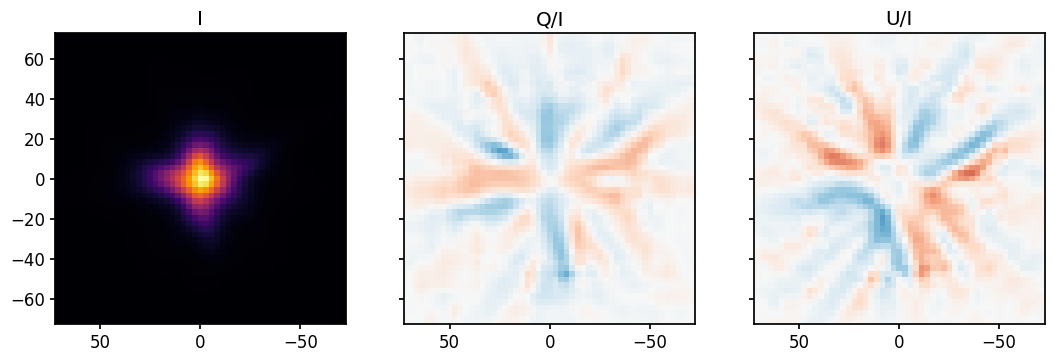

In [6]:
fig, axs = plt.subplots(ncols=3, figsize=(12, 3.5), sharex=True, sharey=True)

axs[0].pcolormesh(source.pixel_centers, source.pixel_centers, pred_i, vmin=0, cmap="inferno")
axs[1].pcolormesh(source.pixel_centers, source.pixel_centers, pred_q, vmin=-0.3, vmax=0.3, cmap="RdBu")
axs[2].pcolormesh(source.pixel_centers, source.pixel_centers, pred_u, vmin=-0.3, vmax=0.3, cmap="RdBu")

axs[0].set_title("I")
axs[1].set_title("Q/I")
axs[2].set_title("U/I")

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlim(source.pixel_centers[-1], source.pixel_centers[0])
    ax.set_ylim(source.pixel_centers[0], source.pixel_centers[-1])

## Extended source prediction

Let's suppose we know what the extended source's flux image looks like, with very good resolution (e.g. a Chandra observation). Assuming that flux is stored in `data/prediction/pwn-i.fits`, 

In [7]:
source = leakagelib.Source.load_file("data/prediction/pwn-i.fits")

Now we'll give it a model polarization map, and ask what the resulting leakage pattern is.

In [8]:
source.polarize_file(("data/prediction/pwn-q.fits", "data/prediction/pwn-u.fits"))

The original I, Q, and U images stored in these files are

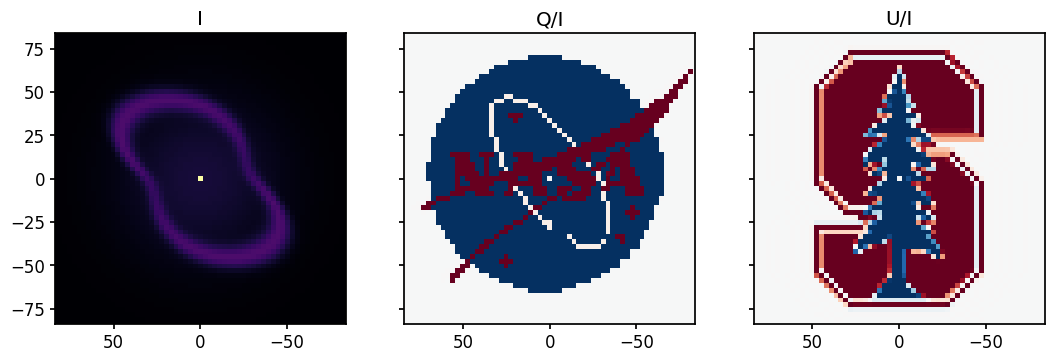

In [9]:
fig, axs = plt.subplots(ncols=3, figsize=(12, 3.5), sharex=True, sharey=True)

axs[0].pcolormesh(source.pixel_centers, source.pixel_centers, source.source, vmin=0, cmap="inferno")
axs[1].pcolormesh(source.pixel_centers, source.pixel_centers, source.q_map/source.source, vmin=-0.3, vmax=0.3, cmap="RdBu")
axs[2].pcolormesh(source.pixel_centers, source.pixel_centers, source.u_map/source.source, vmin=-0.3, vmax=0.3, cmap="RdBu")

axs[0].set_title("I")
axs[1].set_title("Q/I")
axs[2].set_title("U/I")

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlim(source.pixel_centers[-1], source.pixel_centers[0])
    ax.set_ylim(source.pixel_centers[0], source.pixel_centers[-1])

The X and Y units are arcseconds. The leakage patterns are found in the same way as above.

In [10]:
psf = leakagelib.PSF.sky_cal(3, source, 0)
combo = leakagelib.PSFSourceCombo(source, psf, use_nn=False)
pred_i, pred_q, pred_u = combo.compute_leakage(spectrum, normalize=True)

The following code plots the polarization patterns --- that is, predictions for what the detector actually sees.

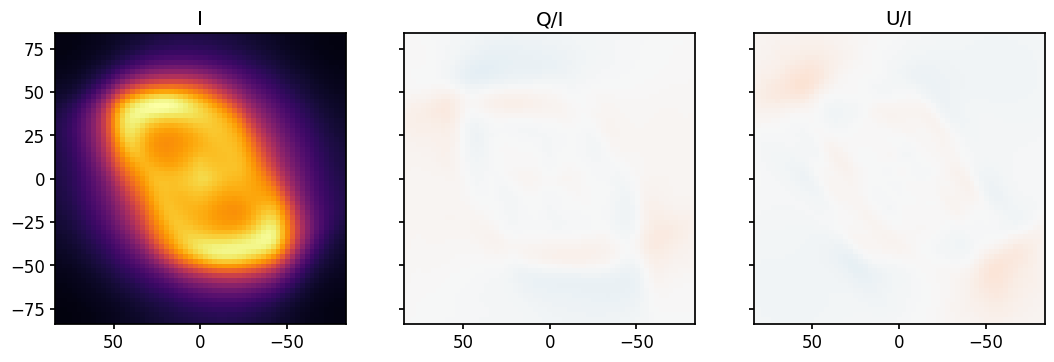

In [11]:
fig, axs = plt.subplots(ncols=3, figsize=(12, 3.5), sharex=True, sharey=True)

axs[0].pcolormesh(source.pixel_centers, source.pixel_centers, pred_i, vmin=0, cmap="inferno")
axs[1].pcolormesh(source.pixel_centers, source.pixel_centers, pred_q, vmin=-0.3, vmax=0.3, cmap="RdBu")
axs[2].pcolormesh(source.pixel_centers, source.pixel_centers, pred_u, vmin=-0.3, vmax=0.3, cmap="RdBu")

axs[0].set_title("I")
axs[1].set_title("Q/I")
axs[2].set_title("U/I")

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlim(source.pixel_centers[-1], source.pixel_centers[0])
    ax.set_ylim(source.pixel_centers[0], source.pixel_centers[-1])

As you see, the predictions are much lower than the true source polarization. That's because LeakageLib computes the predicted detector output, which is lower than the truth by a factor of mu. You can re-plot after dividing by mu to correct this effect.

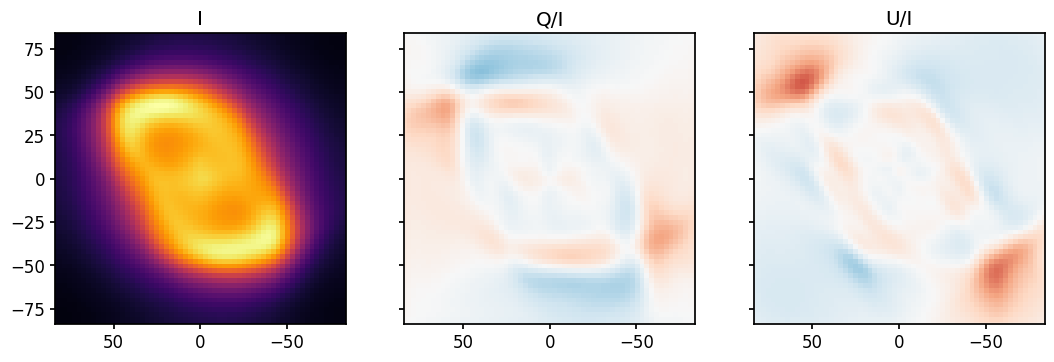

In [12]:
one_over_mu = spectrum.get_avg_one_over_mu(use_nn=False)

fig, axs = plt.subplots(ncols=3, figsize=(12, 3.5), sharex=True, sharey=True)

axs[0].pcolormesh(source.pixel_centers, source.pixel_centers, pred_i, vmin=0, cmap="inferno")
axs[1].pcolormesh(source.pixel_centers, source.pixel_centers, pred_q*one_over_mu, vmin=-0.3, vmax=0.3, cmap="RdBu")
axs[2].pcolormesh(source.pixel_centers, source.pixel_centers, pred_u*one_over_mu, vmin=-0.3, vmax=0.3, cmap="RdBu")

axs[0].set_title("I")
axs[1].set_title("Q/I")
axs[2].set_title("U/I")

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlim(source.pixel_centers[-1], source.pixel_centers[0])
    ax.set_ylim(source.pixel_centers[0], source.pixel_centers[-1])